STRATEGY ORCHESTRATOR - Phase 2 (Updated)

Welcome! I'm your AI Investment Assistant.
Currently trading: AAPL

Supported queries:
  - 'Show me momentum strategies'
  - 'Analyze this strategy: buy when RSI < 30 and MACD positive'
  - 'What should I trade now?'
  - 'Give me low-risk RSI strategies'
  - 'Top performing strategies'

Type 'quit' or 'exit' to end.



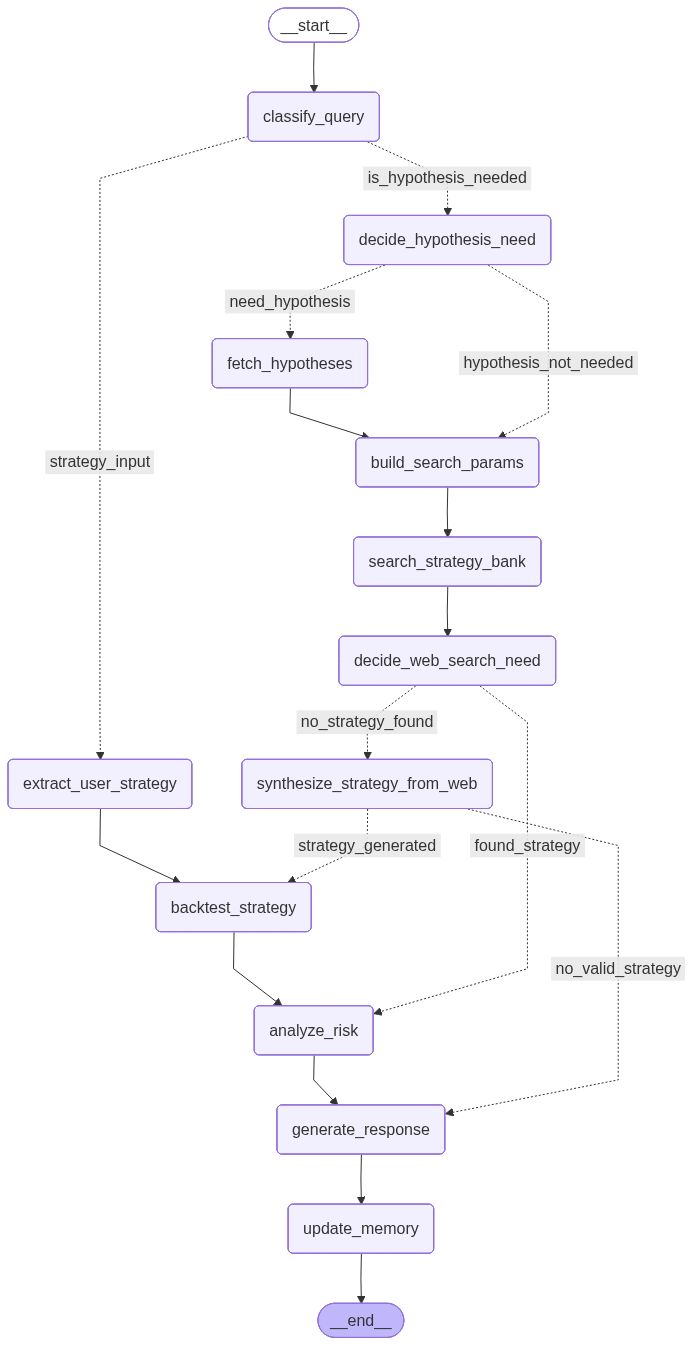

In [10]:
"""
Strategy Orchestrator - LangGraph Implementation v2
Phase 2 Strategy Management System with MCP Integration
"""

import json
import requests
from typing import TypedDict, Annotated, Sequence, Literal
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_anthropic import ChatAnthropic
from langchain_community.tools import DuckDuckGoSearchRun
import operator

# ============================================================================
# CONFIGURATION
# ============================================================================

# FastAPI endpoint for strategy search/backtest
STRATEGY_API_ENDPOINT = "http://localhost:8004/strategy-operations"

# MCP Server endpoints
RISK_ANALYSIS_MCP = "http://localhost:8001/analyze-risk"
HYPOTHESIS_MCP = "http://localhost:8003/get-hypotheses"

# Trading symbol
TRADING_SYMBOL = "AAPL"

# ============================================================================
# STATE DEFINITION
# ============================================================================

class AgentState(TypedDict):
    """State maintained throughout the conversation"""
    messages: Annotated[Sequence[BaseMessage], operator.add]
    user_query: str
    query_type: str  # "request_strategy" | "input_strategy" | "general" | "risk_based" | "hypothesis_based" | "performance"
    user_inputted_strategy: dict  # If user provides a strategy directly
    need_hypothesis: bool
    hypotheses: list
    search_params: dict
    strategies_found: list
    selected_strategy: dict  # Final strategy to analyze
    backtest_results: dict
    web_search_results: list
    risk_analyses: dict
    final_response: str
    conversation_history: list


# ============================================================================
# TOOL FUNCTIONS
# ============================================================================

def call_risk_analysis_mcp(symbol: str, strategy: dict, risk_levels: list) -> dict:
    """Call Risk Analysis MCP Server"""
    try:
        payload = {
            "symbol": symbol,
            "strategy": strategy,
            "risk_levels": risk_levels
        }
        response = requests.post(RISK_ANALYSIS_MCP, json=payload, timeout=30)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Error calling Risk Analysis MCP: {e}")
        return {}


def call_hypothesis_mcp() -> list:
    """Call Hypothesis Generator MCP Server"""
    try:
        response = requests.get(HYPOTHESIS_MCP, timeout=10)
        response.raise_for_status()
        return response.json().get("hypotheses", [])
    except Exception as e:
        print(f"Error calling Hypothesis MCP: {e}")
        return []


def call_strategy_api_search(search_params: dict) -> dict:
    """
    Call FastAPI endpoint for strategy search
    Endpoint expects: {"operation": "get_strategies", "search_params": {...}}
    """
    try:
        payload = {
            "operation": "get_strategies",
            "search_params": search_params
        }
        response = requests.post(STRATEGY_API_ENDPOINT, json=payload, timeout=20)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Error calling Strategy API (search): {e}")
        return {"results": {"strategies": []}}


def call_strategy_api_backtest(strategy: dict) -> dict:
    """
    Call FastAPI endpoint to input strategy and backtest
    Endpoint expects: {"operation": "input_and_backtest", "strategy": {...}}
    """
    try:
        payload = {
            "operation": "input_and_backtest",
            "strategy": strategy
        }
        response = requests.post(STRATEGY_API_ENDPOINT, json=payload, timeout=30)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Error calling Strategy API (backtest): {e}")
        return {}


def web_search_tool(query: str) -> str:
    """
    Web search tool that can be called by the LLM
    Returns search results as a formatted string
    """
    try:
        search = DuckDuckGoSearchRun()
        results = search.run(query)
        return f"Search results for '{query}':\n{results[:1000]}"
    except Exception as e:
        return f"Error performing search: {str(e)}"


# ============================================================================
# LLM SETUP
# ============================================================================

# Define web search as a tool for the LLM
from langchain_core.tools import tool

@tool
def web_search(query: str) -> str:
    """
    Search the web for trading strategy information.
    Use this tool to find technical trading strategies, indicators, entry/exit rules, etc.
    
    Args:
        query: The search query (e.g., "RSI oversold strategy", "MACD crossover trading")
    
    Returns:
        Search results as text
    """
    return web_search_tool(query)

llm = ChatAnthropic(
    model="claude-sonnet-4-20250514",
    temperature=0.7,
    max_tokens=4096
)

# LLM with tools for strategy synthesis
llm_with_tools = llm.bind_tools([web_search])


# ============================================================================
# NODE FUNCTIONS
# ============================================================================

def classify_query(state: AgentState) -> AgentState:
    """Classify user query into one of five types"""
    
    classification_prompt = f"""Classify this user query into exactly ONE category:

User Query: "{state['user_query']}"

Categories:
1. "request_strategy" - User asks for strategies (e.g., "show me momentum strategies", "find RSI strategies")
2. "input_strategy" - User provides a strategy to analyze (e.g., "analyze this strategy: buy when RSI<30", "I want to test MA crossover")
3. "risk_based" - Risk-specific requests (e.g., "give me low-risk strategies")
4. "hypothesis_based" - Current market condition queries (e.g., "what should I trade now")
5. "performance" - Performance-focused queries (e.g., "top performing strategies")

Respond with ONLY the category name, nothing else."""

    response = llm.invoke([HumanMessage(content=classification_prompt)])
    query_type = response.content.strip().lower()
    
    # Validate classification
    valid_types = ["request_strategy", "input_strategy", "risk_based", "hypothesis_based", "performance"]
    if query_type not in valid_types:
        query_type = "request_strategy"  # Default fallback
    
    state["query_type"] = query_type
    state["messages"].append(AIMessage(content=f"[Classified as: {query_type}]"))
    
    return state


def route_after_classification(state: AgentState) -> str:
    """Route based on query type"""
    if state["query_type"] == "input_strategy":
        return "extract_user_strategy"
    else:
        return "decide_hypothesis_need"


def extract_user_strategy(state: AgentState) -> AgentState:
    """Extract strategy from user input"""
    
    extraction_prompt = f"""The user has provided a trading strategy. Extract it into structured format.

User Query: "{state['user_query']}"

Extract the strategy and format as JSON:
{{
  "name": "Strategy name",
  "category": "user",
  "technical_indicators": ["List of indicators"],
  "entry_rules": {{
    "conditions": ["Condition 1", "Condition 2"],
    "logic": "AND | OR"
  }},
  "exit_rules": {{
    "stop_loss_pct": 5.0,
    "take_profit_pct": 10.0,
    "trailing_stop": false
  }}
}}

If the user query doesn't contain a complete strategy, make reasonable assumptions for missing parts.
Respond with ONLY valid JSON, no other text."""

    response = llm.invoke([HumanMessage(content=extraction_prompt)])
    
    try:
        content = response.content.strip()
        # Remove markdown code blocks
        if content.startswith("```"):
            content = content.split("```")[1]
            if content.startswith("json"):
                content = content[4:]
        content = content.strip()
        
        strategy = json.loads(content)
        state["user_inputted_strategy"] = strategy
        state["messages"].append(AIMessage(content=f"[Extracted user strategy: {strategy.get('name')}]"))
        
    except Exception as e:
        print(f"Error extracting strategy: {e}")
        state["user_inputted_strategy"] = {}
    
    return state


def decide_hypothesis_need(state: AgentState) -> AgentState:
    """Decide if hypothesis is needed for strategy search"""
    
    decision_prompt = f"""Does this query require current market hypothesis to answer?

User Query: "{state['user_query']}"
Query Type: {state['query_type']}

Answer YES if:
- User asks "what should I trade now"
- User asks for strategies for "current conditions"
- User asks "best strategy given recent events"

Answer NO if:
- User asks for general strategy types (momentum, reversal, etc.)
- User asks for specific indicator strategies
- User asks for performance-based filtering

Respond with ONLY: YES or NO"""

    response = llm.invoke([HumanMessage(content=decision_prompt)])
    need_hypothesis = "yes" in response.content.strip().lower()
    
    state["need_hypothesis"] = need_hypothesis
    state["messages"].append(AIMessage(content=f"[Hypothesis needed: {need_hypothesis}]"))
    
    return state


def route_hypothesis_decision(state: AgentState) -> str:
    """Route based on hypothesis need"""
    if state["need_hypothesis"]:
        return "fetch_hypotheses"
    else:
        return "build_search_params"


def fetch_hypotheses(state: AgentState) -> AgentState:
    """Fetch current market hypotheses"""
    
    hypotheses = call_hypothesis_mcp()
    state["hypotheses"] = hypotheses
    
    if hypotheses:
        top_hypothesis = hypotheses[0]
        state["messages"].append(AIMessage(
            content=f"[Fetched top hypothesis: {top_hypothesis.get('statement', 'N/A')} - {top_hypothesis.get('direction', 'N/A')}]"
        ))
    else:
        state["messages"].append(AIMessage(content="[No hypotheses available]"))
    
    return state


def build_search_params(state: AgentState) -> AgentState:
    """Build search parameters for Strategy Bank"""
    
    # Build context for LLM
    context = {
        "user_query": state["user_query"],
        "query_type": state["query_type"],
        "hypotheses": state.get("hypotheses", [])
    }
    
    param_prompt = f"""Build strategy search parameters from this context:

Context:
{json.dumps(context, indent=2)}

Build a JSON search parameter object:
{{
  "filters": {{
    "technical_indicators": ["RSI", "MACD"],  // If mentioned
    "category": "book | user | llm | all",
    "performance_criteria": {{
      "min_win_rate": 0.6,
      "min_sharpe_ratio": 1.5
    }},
    "time_window": "30d | 90d | 180d",
    "market_conditions": {{
      "volatility": "low | moderate | high | any",
      "trend": "bullish | bearish | sideways | any"
    }}
  }},
  "sort_by": "rank | sharpe | win_rate | total_return",
  "limit": 5
}}

Guidelines:
- If hypothesis present, set trend to hypothesis direction
- Default time_window: "30d"
- Default sort_by: "rank"
- Only include filters that are relevant
- For general queries, keep filters minimal

Respond with ONLY valid JSON."""

    response = llm.invoke([HumanMessage(content=param_prompt)])
    
    try:
        content = response.content.strip()
        if content.startswith("```"):
            content = content.split("```")[1]
            if content.startswith("json"):
                content = content[4:]
        content = content.strip()
        
        search_params = json.loads(content)
        state["search_params"] = search_params
        state["messages"].append(AIMessage(content=f"[Built search parameters]"))
        
    except Exception as e:
        print(f"Error building search params: {e}")
        # Fallback to default params
        state["search_params"] = {
            "filters": {"time_window": "30d"},
            "sort_by": "rank",
            "limit": 5
        }
    
    return state


def search_strategy_bank(state: AgentState) -> AgentState:
    """Search Strategy Bank via FastAPI"""
    
    search_params = state.get("search_params", {})
    
    # Call FastAPI endpoint
    search_results = call_strategy_api_search(search_params)
    strategies = search_results.get("results", {}).get("strategies", [])
    
    state["strategies_found"] = strategies
    state["messages"].append(AIMessage(
        content=f"[Found {len(strategies)} strategies in Strategy Bank]"
    ))
    
    return state


def decide_web_search_need(state: AgentState) -> AgentState:
    """Decide if web search is needed based on search results"""
    
    strategies = state.get("strategies_found", [])
    
    if len(strategies) > 0:
        # We found strategies in the bank, select the top one
        top_strategy = strategies[0]
        state["selected_strategy"] = top_strategy
        state["messages"].append(AIMessage(
            content=f"[Selected top strategy from bank: {top_strategy.get('name')}]"
        ))
    else:
        # No strategies found, we'll need web search
        state["messages"].append(AIMessage(
            content="[No strategies found in bank, will search the web]"
        ))
    
    return state


def synthesize_strategy_from_web(state: AgentState) -> AgentState:
    """Synthesize a strategy using LLM with web search tool"""
    
    # Build context including search params if available
    context_info = {
        "user_query": state["user_query"],
        "query_type": state["query_type"],
        "search_params": state.get("search_params", {}),
        "hypotheses": state.get("hypotheses", [])
    }
    
    max_searches = 2  # Maximum number of web searches allowed
    
    state["messages"].append(AIMessage(
        content="[Starting web-based strategy synthesis with search tool]"
    ))
    
    synthesis_prompt = f"""You are tasked with creating a technical trading strategy based on the user's request.

User Query: "{state['user_query']}"

Context:
{json.dumps(context_info, indent=2)}

You have access to a web_search tool. Use it strategically (maximum {max_searches} searches) to find:
1. Technical indicators and their parameters
2. Entry/exit conditions
3. Risk management rules (stop-loss, take-profit)

CRITICAL REQUIREMENTS:
1. DO NOT fabricate or make up strategy details
2. ONLY create a strategy if you find clear, complete information through your searches
3. Each search query should be specific (e.g., "RSI oversold buy signal strategy", "MACD crossover entry rules")
4. After searching, evaluate if you have enough information to create a complete strategy

If you CAN create a valid strategy from your search results, respond with:
{{
  "status": "found",
  "strategy": {{
    "name": "Descriptive strategy name based on search findings",
    "category": "llm",
    "technical_indicators": ["List of specific indicators found"],
    "entry_rules": {{
      "conditions": ["Specific condition 1 from search", "Specific condition 2 from search"],
      "logic": "AND"
    }},
    "exit_rules": {{
      "stop_loss_pct": <number from search or reasonable default>,
      "take_profit_pct": <number from search or reasonable default>,
      "trailing_stop": <true/false>
    }}
  }},
  "search_summary": "Brief summary of what you found and which searches you used"
}}

If you CANNOT find sufficient information after your searches, respond with:
{{
  "status": "not_found",
  "reason": "Specific explanation of what information is missing",
  "searches_performed": ["List of search queries you tried"]
}}

Think step by step:
1. Identify what information you need
2. Perform targeted searches
3. Evaluate if you have complete information
4. Generate the strategy or return not_found

Respond with ONLY valid JSON."""

    from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
    
    messages = [HumanMessage(content=synthesis_prompt)]
    search_count = 0
    
    # Allow the LLM to use tools iteratively
    for iteration in range(5):  # Max iterations to prevent infinite loops
        response = llm_with_tools.invoke(messages)
        messages.append(response)
        
        # Check if the LLM wants to use tools
        if response.tool_calls:
            for tool_call in response.tool_calls:
                if search_count >= max_searches:
                    # Exceeded search limit
                    tool_result = f"Search limit reached ({max_searches} searches). Please provide your final answer based on the information gathered."
                else:
                    # Execute the tool
                    if tool_call["name"] == "web_search":
                        search_query = tool_call["args"]["query"]
                        search_count += 1
                        tool_result = web_search_tool(search_query)
                        state["messages"].append(AIMessage(
                            content=f"[Search {search_count}/{max_searches}: '{search_query}']"
                        ))
                    else:
                        tool_result = "Unknown tool"
                
                # Add tool result to messages
                messages.append(ToolMessage(
                    content=tool_result,
                    tool_call_id=tool_call["id"]
                ))
        else:
            # No more tool calls, LLM has provided final answer
            break
    
    # Extract the final response
    final_response = messages[-1].content if not messages[-1].tool_calls else ""
    
    try:
        # Parse the JSON response
        content = final_response.strip()
        if content.startswith("```"):
            content = content.split("```")[1]
            if content.startswith("json"):
                content = content[4:]
        content = content.strip()
        
        result = json.loads(content)
        
        if result.get("status") == "found" and "strategy" in result:
            strategy = result["strategy"]
            state["selected_strategy"] = strategy
            search_summary = result.get("search_summary", "")
            state["messages"].append(AIMessage(
                content=f"[Synthesized strategy: {strategy.get('name')}. {search_summary}]"
            ))
        else:
            # Strategy not found
            state["selected_strategy"] = {}
            reason = result.get("reason", "Insufficient information in search results")
            searches = result.get("searches_performed", [])
            state["messages"].append(AIMessage(
                content=f"[Could not synthesize strategy: {reason}. Searches: {', '.join(searches)}]"
            ))
        
    except Exception as e:
        print(f"Error synthesizing strategy: {e}")
        state["selected_strategy"] = {}
        state["messages"].append(AIMessage(
            content=f"[Error during strategy synthesis: {str(e)}]"
        ))
    
    return state


def route_after_web_search_decision(state: AgentState) -> str:
    """Route after deciding on web search"""
    if state.get("selected_strategy"):
        # Found strategy in bank, skip to risk analysis or backtest first
        # Check if it already has backtest results
        return "found_strategy"
    else:
        # No strategy found, perform web search
        return "no_strategy_found"


def route_after_synthesis(state: AgentState) -> str:
    """Route after web synthesis"""
    if state.get("selected_strategy"):
        # Strategy was successfully synthesized, backtest it
        return "strategy_generated"
    else:
        # Could not synthesize strategy, generate response explaining why
        return "no_valid_strategy"


def backtest_strategy(state: AgentState) -> AgentState:
    """Backtest the selected strategy via FastAPI"""
    
    # Determine which strategy to backtest
    if state.get("user_inputted_strategy"):
        strategy = state["user_inputted_strategy"]
    elif state.get("selected_strategy"):
        strategy = state["selected_strategy"]
    else:
        state["messages"].append(AIMessage(content="[No strategy to backtest]"))
        return state
    
    # Call FastAPI endpoint to backtest
    backtest_results = call_strategy_api_backtest(strategy)
    
    state["backtest_results"] = backtest_results
    state["selected_strategy"] = strategy  # Ensure selected_strategy is set
    
    state["messages"].append(AIMessage(
        content=f"[Backtested strategy: {strategy.get('name')}]"
    ))
    
    return state


def analyze_risk(state: AgentState) -> AgentState:
    """Get risk analysis for the selected strategy"""
    
    strategy = state.get("selected_strategy", {})
    
    if not strategy:
        state["messages"].append(AIMessage(content="[No strategy to analyze]"))
        return state
    
    # Call risk analysis MCP for all three risk levels
    risk_result = call_risk_analysis_mcp(
        symbol=TRADING_SYMBOL,
        strategy=strategy,
        risk_levels=["no_risk", "neutral", "aggressive"]
    )
    
    state["risk_analyses"] = risk_result
    state["messages"].append(AIMessage(
        content=f"[Obtained risk analysis for all three tiers]"
    ))
    
    return state


def generate_response(state: AgentState) -> AgentState:
    """Generate final response to user"""
    
    # Build context
    context = {
        "query": state["user_query"],
        "query_type": state["query_type"],
        "strategy": state.get("selected_strategy", {}),
        "backtest_results": state.get("backtest_results", {}),
        "risk_analyses": state.get("risk_analyses", {}),
        "hypotheses": state.get("hypotheses", [])
    }
    
    response_prompt = f"""You are the Strategy Orchestrator. Generate a comprehensive response.

User Query: "{state['user_query']}"

Context:
{json.dumps(context, indent=2)[:4000]}

Instructions:
1. Start with context (hypothesis if available)
2. Present the strategy:
   - Name and description
   - Technical indicators used
   - Entry and exit rules
3. Show backtest results:
   - Key performance metrics (win rate, sharpe ratio, max drawdown)
   - Return statistics
   - Trade statistics
4. Present risk analysis for all three tiers:
   - No-Risk: approval status, recommended params, key concerns
   - Neutral: approval status, recommended params, conviction level
   - Aggressive: approval status, recommended params, upside potential
5. Provide a recommendation based on current market conditions
6. Ask if user wants more details or wants to analyze another strategy

Format:
- Use clear sections with headers
- Use bullet points for metrics
- Be specific with numbers
- Sound professional but conversational

If no strategy was found, explain why and suggest alternatives."""

    response = llm.invoke([HumanMessage(content=response_prompt)])
    final_response = response.content
    
    state["final_response"] = final_response
    state["messages"].append(AIMessage(content=final_response))
    
    return state


def update_memory(state: AgentState) -> AgentState:
    """Update conversation memory"""
    
    conversation_entry = {
        "user_query": state["user_query"],
        "query_type": state["query_type"],
        "strategy": state.get("selected_strategy", {}).get("name", "N/A"),
        "response_summary": state["final_response"][:200]
    }
    
    if "conversation_history" not in state:
        state["conversation_history"] = []
    
    state["conversation_history"].append(conversation_entry)
    
    # Keep last 5 exchanges
    if len(state["conversation_history"]) > 5:
        state["conversation_history"] = state["conversation_history"][-5:]
    
    return state


# ============================================================================
# BUILD LANGGRAPH
# ============================================================================

def build_graph():
    """Build the LangGraph workflow"""
    
    workflow = StateGraph(AgentState)
    
    # Add all nodes
    workflow.add_node("classify_query", classify_query)
    workflow.add_node("extract_user_strategy", extract_user_strategy)
    workflow.add_node("decide_hypothesis_need", decide_hypothesis_need)
    workflow.add_node("fetch_hypotheses", fetch_hypotheses)
    workflow.add_node("build_search_params", build_search_params)
    workflow.add_node("search_strategy_bank", search_strategy_bank)
    workflow.add_node("synthesize_strategy_from_web", synthesize_strategy_from_web)
    workflow.add_node("backtest_strategy", backtest_strategy)
    workflow.add_node("analyze_risk", analyze_risk)
    workflow.add_node("generate_response", generate_response)
    workflow.add_node("update_memory", update_memory)
    workflow.add_node("decide_web_search_need", decide_web_search_need)
    
    # Set entry point
    workflow.set_entry_point("classify_query")
    
    # Add edges
    workflow.add_conditional_edges(
        "classify_query",
        route_after_classification,
        {
            "strategy_input": "extract_user_strategy",
            "is_hypothesis_needed": "decide_hypothesis_need"
        }
    )
    
    workflow.add_edge("extract_user_strategy", "backtest_strategy")
    
    workflow.add_conditional_edges(
        "decide_hypothesis_need",
        route_hypothesis_decision,
        {
            "need_hypothesis": "fetch_hypotheses",
            "hypothesis_not_needed": "build_search_params"
        }
    )
    
    workflow.add_edge("fetch_hypotheses", "build_search_params")
    workflow.add_edge("build_search_params", "search_strategy_bank")
    workflow.add_edge("search_strategy_bank", "decide_web_search_need")
    
    workflow.add_conditional_edges(
        "decide_web_search_need",
        route_after_web_search_decision,
        {
            "found_strategy": "analyze_risk",
            "no_strategy_found": "synthesize_strategy_from_web",
        }
    )
    
    workflow.add_conditional_edges(
        "synthesize_strategy_from_web",
        route_after_synthesis,
        {
            "no_valid_strategy": "generate_response",
            "strategy_generated": "backtest_strategy",
        }
    )
    
    workflow.add_edge("backtest_strategy", "analyze_risk")
    workflow.add_edge("analyze_risk", "generate_response")
    workflow.add_edge("generate_response", "update_memory")
    workflow.add_edge("update_memory", END)
    
    return workflow.compile()


def print_graph(graph):
    """Print the LangGraph structure"""

    # New visualization using graph helper
    graph_repr = graph.get_graph()  # returns a visualizable graph helper

    # Generate Mermaid diagram as PNG
    mermaid_png_bytes = graph_repr.draw_mermaid_png()

    # Display PNG (Jupyter-safe)
    from IPython.display import Image, display
    display(Image(mermaid_png_bytes))


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution loop"""
    
    print("=" * 70)
    print("STRATEGY ORCHESTRATOR - Phase 2 (Updated)")
    print("=" * 70)
    print("\nWelcome! I'm your AI Investment Assistant.")
    print(f"Currently trading: {TRADING_SYMBOL}")
    print("\nSupported queries:")
    print("  - 'Show me momentum strategies'")
    print("  - 'Analyze this strategy: buy when RSI < 30 and MACD positive'")
    print("  - 'What should I trade now?'")
    print("  - 'Give me low-risk RSI strategies'")
    print("  - 'Top performing strategies'")
    print("\nType 'quit' or 'exit' to end.\n")
    
    # Build and print graph
    graph = build_graph()
    print_graph(graph)  # Commented out - causes timeout with mermaid.ink
    
    # # Initialize conversation history
    # conversation_history = []
    
    # while True:
    #     # Get user input
    #     user_query = input("\n🤔 You: ").strip()
        
    #     if not user_query:
    #         continue
        
    #     if user_query.lower() in ['quit', 'exit', 'q']:
    #         print("\n👋 Goodbye! Happy trading!\n")
    #         break
        
    #     # Initialize state
    #     initial_state = {
    #         "messages": [HumanMessage(content=user_query)],
    #         "user_query": user_query,
    #         "query_type": "",
    #         "user_inputted_strategy": {},
    #         "need_hypothesis": False,
    #         "hypotheses": [],
    #         "search_params": {},
    #         "strategies_found": [],
    #         "selected_strategy": {},
    #         "backtest_results": {},
    #         "web_search_results": [],
    #         "risk_analyses": {},
    #         "final_response": "",
    #         "conversation_history": conversation_history
    #     }
        
    #     print("\n🤖 Processing...")
        
    #     try:
    #         # Run graph
    #         final_state = graph.invoke(initial_state)
            
    #         # Print response
    #         print("\n" + "=" * 70)
    #         print("📊 ORCHESTRATOR RESPONSE:")
    #         print("=" * 70)
    #         print(final_state["final_response"])
    #         print("=" * 70)
            
    #         # Update conversation history
    #         conversation_history = final_state.get("conversation_history", [])
            
    #     except Exception as e:
    #         print(f"\n❌ Error: {e}")
    #         import traceback
    #         traceback.print_exc()
    #         print("Please try again or rephrase your query.\n")


if __name__ == "__main__":
    main()
    # import os
    # if not os.getenv("ANTHROPIC_API_KEY"):
    #     print("⚠️  Warning: ANTHROPIC_API_KEY environment variable not set!")
    #     print("Please set it: export ANTHROPIC_API_KEY='your-key'\n")
    
    # try:
    #     main()
    # except KeyboardInterrupt:
    #     print("\n\n👋 Interrupted. Goodbye!\n")
    # except Exception as e:
    #     print(f"\n❌ Fatal error: {e}\n")
    #     import traceback
    #     traceback.print_exc()